# GISLR — Continuous models on GISLR-Sentences (vs the §12.2 baselines)

**What this notebook does.** Diagnostic, TODO §12.3. It scores the
continuous-signing models trained in `gislr.1.models.continuous.ipynb` on
GISLR-Sentences, using **exactly** the protocol of
`gislr.3.streaming.sentence-baselines.ipynb`:
- decoder settings are chosen on the same 5 seeded selection signers of the
  `sentence` split, and every reported number uses the other 16;
- the same metrics (`sb.recognize.sequences.metrics`);
- both splits, with null frames and hard-cut.

The result table puts the continuous models next to the baselines' rows
(read from their cached `final.json`).

**Runs:** C1 (GRU), C2 (LSTM) and C3 (CTC). The open-vocabulary run is §12.4's.
A run that is missing or still training is skipped with a message.

**Decoders** (`sb.recognize.continuous.decode`; all emit into the same scorer)

| id | what | params |
|---|---|---|
| **D1** | commit where the **boundary head** rises through β, emitting the gloss with the most non-null probability mass since the previous commit. No hold | β, min_mass |
| **D1r** | D1 + recurrent-state reset after every commit (the user's "reset for the next sign") | β, min_mass |
| **D2** | the user's literal loop on the new model: top gloss ≥ τ for `hold` frames → emit + reset; null can never be accepted | τ, hold |
| **D3** | commit at the end of each run of non-null frames. Cannot split back-to-back signs | ν, min_len |
| **D4** | greedy CTC: per-frame argmax, repeats collapsed, null dropped | — |

Each is also scored with consecutive repeats collapsed, as in §12.2.

**Diagnostics (§2):**
- frame accuracy;
- isolated read-out per true segment (fresh state), the analogue of the baselines' B1;
- in-context segment vote (no reset, true boundaries);
- boundary F1 (±3 frames).

**By sign length (§5):** the §12.2 diagnostic (short and long signs need
opposite holds) redone under real decoding, the best continuous decoder
against the best reset-on-accept baseline (`lstm` B2 collapsed).

**Artifacts** (`data/cache/gislr/continuous_eval/results/`):
`diag_<run>.json`, `sweep_<run>.json`, `sweep_ext_<run>.json`, `final_parts/*.json`,
`final.json`, `final_table.csv`,
`by_length.csv`, `assets/*.png`. Resumable: a cell skips any file that
already exists. `LIMIT_PER_GROUP` makes a smoke run into `results_smoke/`.

**Caveats carried in from §12.2:**
- v1's rest is the hands-absent kind (the continuous models also trained on
  a realistic lowered-hands rest);
- clips are fed at native length;
- `gru_reg` in the baseline rows was checkpoint-selected on `test.csv`.

## Setup

In [1]:
# ============================================================
# Imports, config, dataset, signer split, models
# ============================================================
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from sb.core.paths import CACHE_DIR, EXPERIMENTS_DIR, gislr_sentences_dir
from sb.mlops import registry as R
from sb.recognize import streaming as S
from sb.recognize.continuous import decode as CDEC
from sb.recognize.continuous import phono as CPH
from sb.recognize.continuous.train import load_run, run_dir_for
from sb.recognize.sequences import baselines as B
from sb.recognize.sequences import metrics as M
from sb.recognize.sequences.compose import SIGN

CONFIG_DIR = EXPERIMENTS_DIR / "recognition" / "configs"
CONFIG = json.loads((CONFIG_DIR / "gislr.continuous-eval.json").read_text(encoding="utf-8"))
BASE_CONFIG = json.loads((CONFIG_DIR / "gislr.sentence-baselines.json").read_text(encoding="utf-8"))

LIMIT_PER_GROUP = None  # e.g. 20 -> quick smoke run, written to results_smoke/

DATASET_ROOT = gislr_sentences_dir(CONFIG["dataset_version"])
OUT = CACHE_DIR / "gislr" / "continuous_eval" / ("results" if LIMIT_PER_GROUP is None else "results_smoke")
ASSETS = OUT / "assets"
ASSETS.mkdir(parents=True, exist_ok=True)
BASE_OUT = CACHE_DIR / CONFIG["baselines_results"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)

SEQ_FULL = pd.read_csv(DATASET_ROOT / "sequences.csv", keep_default_na=False)
SEQ = SEQ_FULL.copy()
SEQ["row"] = np.arange(len(SEQ))
SELECT, EVAL = B.signer_split(SEQ["participant_id"], CONFIG["n_selection_signers"], CONFIG["seed"])
assert (SELECT, EVAL) == B.signer_split(SEQ["participant_id"], BASE_CONFIG["n_selection_signers"], BASE_CONFIG["seed"]), \
    "signer split differs from the baselines' -- results would not be comparable"
SEQ["group"] = np.where(SEQ["participant_id"].isin(SELECT), "select", "eval")
if LIMIT_PER_GROUP is not None:
    SEQ = SEQ.groupby(["kind", "group"], group_keys=False).head(LIMIT_PER_GROUP)


def write_json(path: Path, obj) -> None:
    tmp = path.with_suffix(".tmp")
    tmp.write_text(json.dumps(obj, indent=1), encoding="utf-8")
    os.replace(tmp, path)


RUNS = {}
for name in CONFIG["runs"]:
    rd = run_dir_for(name)
    if rd is None or not (rd / "meta.json").exists():
        print(f"{name}: not trained -- skipped")
        continue
    meta = R.load_meta(rd)
    if not meta["training"]["finished"]:
        print(f"{name}: still training ({meta['training']['epochs_trained']} epochs) -- skipped")
        continue
    model, ck = load_run(rd, DEVICE)
    # phonology runs read the 130 phonological features of each stream's raw landmarks (TODO §3.10)
    feats = (CPH.PhonoStreamFeatures.build(DATASET_ROOT, SEQ_FULL) if ck.get("features") == "phono130_v1"
             else B.StreamFeatures.build(DATASET_ROOT, SEQ_FULL, np.asarray(ck["landmarks"]), ck["coords"]))
    RUNS[name] = {"model": model, "arch": ck["arch"], "null": ck["null_index"], "loss": ck["hyp"]["loss"],
                  "feats": feats, "run_dir": rd}
    print(f"{name}: run {rd.name} · {ck['arch']} · loss {ck['hyp']['loss']} · best val seg acc {ck['best_val_acc']:.4f}")


def x_of(feats, i) -> torch.Tensor:
    return torch.from_numpy(np.ascontiguousarray(feats.x(i)))


print(f"dataset: {DATASET_ROOT}\nresults: {OUT}\nselection signers {SELECT}")
print(SEQ.groupby(["kind", "group"]).size().unstack())

gislr_sentences_dir: kaggle copy unavailable (KaggleApiHTTPError); using the local build C:\Users\user2\repository\data\cache\gislr\sentences\v1
C1: run 1790429419 · gru_continuous · loss frame · best val seg acc 0.7233
C2: run 1790430959 · lstm_continuous · loss frame · best val seg acc 0.7103
C3: run 1790432253 · gru_continuous · loss ctc · best val seg acc 0.4934
P1: run 1790416771 · gru_continuous_phono130 · loss frame · best val seg acc 0.6971
C4: run 1790435218 · gru_continuous_norm · loss frame · best val seg acc 0.6929
C5: run 1790435219 · gru_continuous · loss frame · best val seg acc 0.6489
dataset: C:\Users\user2\repository\data\cache\gislr\sentences\v1
results: C:\Users\user2\repository\data\cache\gislr\continuous_eval\results
selection signers [4718, 28656, 29302, 34503, 36257]
group     eval  select
kind                  
control   4639    1472
sentence  5054    1562


## 1. Parity: the fast decoders are the live loop

For each run, on CPU:
1. `RecurrentSession.step`, frame by frame, reproduces the batch per-frame
   probabilities.
2. D2 (`decode_stream` with null excluded) equals the real loop:
   `step` + `AcceptTrigger(exclude=null)` + `reset()` on accept.

The two paths differ by ~1e-6 in float, so a frame whose top probability sits
on τ (or whose top two classes tie) can flip `held` between them. The accept
then moves by a frame and the two resync within a sign. Such a divergence is
counted as a **near-tie** and reported, not failed. Only a mismatch with no
near-tie frame between the last shared emission and the divergence is a
decoder bug. First run (2026-09-23): C1 had one, at p=0.5000002 (live) vs
0.4999995 (batch) with τ=0.5.

In [2]:
# ============================================================
# Session vs batch, and D2 vs the live loop (CPU)
# ============================================================
N_PARITY = 5
PARITY_SETTINGS = [(0.5, 2), (0.7, 5)]
TIE_EPS = 1e-5  # > the session-vs-batch float gap: a frame this close to tau (or an argmax tie) explains a mismatch

cpu = torch.device("cpu")
for name, r in RUNS.items():
    model_cpu, _ = load_run(r["run_dir"], cpu)
    worst, mismatch, ties, total = 0.0, 0, 0, 0
    for i in SEQ["row"].to_numpy()[:N_PARITY]:
        x = x_of(r["feats"], i)
        sess = S.RecurrentSession(model_cpu, r["arch"], cpu)
        step = np.stack([sess.step(x[t]) for t in range(len(x))])
        worst = max(worst, float(np.abs(step - S.per_frame_probs(model_cpu, r["arch"], x)).max()))
        for tau, hold in PARITY_SETTINGS:
            sess, trig, live = S.RecurrentSession(model_cpu, r["arch"], cpu), S.AcceptTrigger(tau, hold, exclude=r["null"]), []
            for t in range(len(x)):
                c = trig.update(sess.step(x[t]))
                if c is not None:
                    live.append((c, t))
                    sess.reset()
            fast = [(c, t) for c, t, _ in S.decode_stream(model_cpu, r["arch"], x, tau, hold, reset=True, exclude=r["null"])]
            total += 1
            if live == fast:
                continue
            # first divergence: fresh-state probs from the last shared reset up to the later of the two accepts
            j = next((k for k, (a, b) in enumerate(zip(live, fast)) if a != b), min(len(live), len(fast)))
            p0 = live[j - 1][1] + 1 if j else 0
            end = max(t for _, t in live[j:j + 1] + fast[j:j + 1]) + 1
            s = np.sort(S.per_frame_probs(model_cpu, r["arch"], x[p0:end]), axis=1)
            near = (np.abs(s[:, -1] - tau) < TIE_EPS) | (s[:, -1] - s[:, -2] < TIE_EPS)
            if near.any():
                ties += 1
            else:
                mismatch += 1
                print(f"  {name} row {i} tau={tau} hold={hold}: live {live[j:j + 1]} vs fast {fast[j:j + 1]}, no near-tie")
    print(f"{name}: session vs batch max |diff| {worst:.2e} · D2 vs live loop {mismatch}/{total} mismatches "
          f"(+{ties} float near-ties at tau)")
    assert worst < 1e-4 and mismatch == 0


C1: session vs batch max |diff| 5.36e-06 · D2 vs live loop 0/10 mismatches (+1 float near-ties at tau)
C2: session vs batch max |diff| 2.09e-06 · D2 vs live loop 0/10 mismatches (+0 float near-ties at tau)
C3: session vs batch max |diff| 1.17e-05 · D2 vs live loop 0/10 mismatches (+0 float near-ties at tau)
P1: session vs batch max |diff| 2.62e-06 · D2 vs live loop 0/10 mismatches (+0 float near-ties at tau)
C4: session vs batch max |diff| 2.83e-06 · D2 vs live loop 0/10 mismatches (+0 float near-ties at tau)
C5: session vs batch max |diff| 2.00e-06 · D2 vs live loop 0/10 mismatches (+0 float near-ties at tau)


## 2. Per-frame diagnostics (evaluation signers, `sentence` split)

No decoder is involved here; these measure the model's raw per-frame outputs.
- **frame accuracy:** argmax over glosses + null, against each frame's label.
- **isolated read-out:** fresh state at each true sign start, read at its last
  frame. Comparable to the baselines' B1.
- **in-context vote:** the full stream with no reset; for each true segment,
  the gloss with the most non-null mass. This is what D1 does given perfect
  boundaries.
- **boundary F1:** upward crossings of 0.5 against true sign ends, ±3 frames.

In [3]:
# ============================================================
# Frame / isolated / in-context / boundary diagnostics per run
# ============================================================
ev = SEQ[(SEQ.group == "eval") & (SEQ.kind == "sentence")]
for name, r in RUNS.items():
    path = OUT / f"diag_{name}.json"
    if path.exists():
        continue
    fc = fn = iso = ctx = nseg = tp = npred = nact = 0
    for _, row in tqdm(ev.iterrows(), total=len(ev), desc=f"diagnostics {name}"):
        x = x_of(r["feats"], row["row"])
        labels, seg = B.seq_arrays(row)
        gp, bp = CDEC.frame_outputs(r["model"], x)
        y = np.full(len(x), r["null"])
        for (s, e), lab in zip(seg, labels):
            y[s:e] = lab
            iso += int(S.clip_probs(r["model"], r["arch"], x[s:e]).argmax() == lab)
            ctx += int(CDEC.segment_vote(gp[s:e], r["null"])[0] == lab)
            nseg += 1
        fc += int((gp.argmax(1) == y).sum())
        fn += len(y)
        up = bp >= 0.5
        pred = np.flatnonzero(up & ~np.r_[False, up[:-1]])
        used = set()
        for e in seg[:, 1] - 1:
            cand = [p for p in pred if abs(p - e) <= CONFIG["boundary_tolerance"] and p not in used]
            if cand:
                used.add(min(cand, key=lambda p: abs(p - e)))
                tp += 1
        npred, nact = npred + len(pred), nact + len(seg)
    prec, rec = tp / max(npred, 1), tp / max(nact, 1)
    write_json(path, {"frame_acc": fc / fn, "isolated_readout_acc": iso / nseg, "in_context_vote_acc": ctx / nseg,
                      "boundary_precision": prec, "boundary_recall": rec,
                      "boundary_f1": 2 * prec * rec / max(prec + rec, 1e-9), "n_signs": nseg})
print(pd.DataFrame({p.stem.removeprefix("diag_"): json.loads(p.read_text()) for p in sorted(OUT.glob("diag_*.json"))}).T
      .to_string(float_format="{:.4f}".format))

diagnostics C4:   0%|          | 0/5054 [00:00<?, ?it/s]

diagnostics C5:   0%|          | 0/5054 [00:00<?, ?it/s]

    frame_acc  isolated_readout_acc  in_context_vote_acc  boundary_precision  boundary_recall  boundary_f1    n_signs
C1     0.7227                0.7460               0.7499              0.3296           0.6403       0.4352 15652.0000
C2     0.7123                0.7434               0.7409              0.3181           0.6462       0.4263 15652.0000
C3     0.3287                0.3660               0.5269              0.1944           0.3718       0.2553 15652.0000
C4     0.7193                0.7651               0.7713              0.2447           0.4670       0.3211 15652.0000
C5     0.6871                0.7128               0.7288              0.2379           0.4911       0.3205 15652.0000
P1     0.4585                0.6706               0.5048              0.2269           0.6910       0.3416 15652.0000


## 3. Decoder sweep (selection signers, `sentence` split)

One forward pass per sequence feeds D1, D3 and D4. D1r and D2 restart the
model at each commit, reusing a per-sequence forward cache.

In [4]:
# ============================================================
# Sweep every decoder setting for every run
# ============================================================
dcfg = CONFIG["decoders"]
sel = SEQ[(SEQ.group == "select") & (SEQ.kind == CONFIG["selection_kind"])]
for name, r in RUNS.items():
    path = OUT / f"sweep_{name}.json"
    if path.exists():
        continue
    settings = ([("D1", {"beta": b, "min_mass": m}) for b in dcfg["D1"]["beta"] for m in dcfg["D1"]["min_mass"]]
                + [("D1r", {"beta": b, "min_mass": m}) for b in dcfg["D1r"]["beta"] for m in dcfg["D1r"]["min_mass"]]
                + [("D2", {"tau": t, "hold": h}) for t in dcfg["D2"]["tau"] for h in dcfg["D2"]["hold"]]
                + [("D3", {"nu": v, "min_len": k}) for v in dcfg["D3"]["nu"] for k in dcfg["D3"]["min_len"]]
                + [("D4", {})])

    def key(d, p):
        return d, tuple(sorted(p.items()))

    scores = {(key(d, p), c): [] for d, p in settings for c in CONFIG["collapse_repeats"]}
    kinds_all = []
    for _, row in tqdm(sel.iterrows(), total=len(sel), desc=f"sweep {name}"):
        x = x_of(r["feats"], row["row"])
        kinds = r["feats"].kind(row["row"])
        labels, seg = B.seq_arrays(row)
        kinds_all.append(kinds)
        gp, bp = CDEC.frame_outputs(r["model"], x)
        cache_b, cache_g = {0: (gp, bp)}, {0: gp}
        for d, p in settings:
            if d == "D1":
                em = CDEC.decode_boundary(gp, bp, p["beta"], p["min_mass"], r["null"])
            elif d == "D1r":
                em = CDEC.decode_boundary_reset(r["model"], x, p["beta"], p["min_mass"], r["null"], cache=cache_b)
            elif d == "D2":
                em = S.decode_stream(r["model"], r["arch"], x, p["tau"], p["hold"], reset=True, cache=cache_g, exclude=r["null"])
            elif d == "D3":
                em = CDEC.decode_null(gp, p["nu"], p["min_len"], r["null"])
            else:
                em = CDEC.decode_ctc(gp, r["null"])
            for c in CONFIG["collapse_repeats"]:
                scores[(key(d, p), c)].append(M.score_sequence(S.collapse_repeats(em) if c else em, labels, seg, kinds))
    ft = B.frame_totals(kinds_all)
    out = [{"decoder": d, **dict(pk), "collapse": c, **M.aggregate(sc, ft)}
           for ((d, pk), c), sc in scores.items()]
    write_json(path, out)
print("sweeps cached:", sorted(p.name for p in OUT.glob("sweep_*.json")))

sweep C4:   0%|          | 0/1562 [00:00<?, ?it/s]

sweep C5:   0%|          | 0/1562 [00:00<?, ?it/s]

sweeps cached: ['sweep_C1.json', 'sweep_C2.json', 'sweep_C3.json', 'sweep_C4.json', 'sweep_C5.json', 'sweep_P1.json', 'sweep_ext_C1.json', 'sweep_ext_C2.json', 'sweep_ext_C3.json', 'sweep_ext_P1.json']


## 3b. Grid extension where §3 picked an edge

§3 chose several settings at the edge of their grid: D1 β=0.7 and min_mass=4
(both the maximum) and D3 ν=0.7 (the maximum), for C1 and C2 (TODO §12.3,
2026-09-24). This cell sweeps `decoders_ext` from the config, skipping any
combination §3 already scored, and writes `sweep_ext_<run>.json`. §4 selects
over both files. D1 and D3 need only the one fresh-state forward pass, so this
is cheap.

In [5]:
# ============================================================
# Sweep the extended D1/D3 grid (only combinations §3 did not score)
# ============================================================
ext = CONFIG["decoders_ext"]
sel = SEQ[(SEQ.group == "select") & (SEQ.kind == CONFIG["selection_kind"])]
for name, r in RUNS.items():
    path = OUT / f"sweep_ext_{name}.json"
    if path.exists():
        continue
    done = pd.DataFrame(json.loads((OUT / f"sweep_{name}.json").read_text()))
    seen = {(d, tuple(round(float(g[k]), 6) for k in ks))
            for d, ks in (("D1", ("beta", "min_mass")), ("D3", ("nu", "min_len")))
            for _, g in done[done.decoder == d].iterrows()}
    settings = ([("D1", {"beta": b, "min_mass": m}) for b in ext["D1"]["beta"] for m in ext["D1"]["min_mass"]]
                + [("D3", {"nu": v, "min_len": k}) for v in ext["D3"]["nu"] for k in ext["D3"]["min_len"]])
    settings = [(d, p) for d, p in settings if (d, tuple(round(float(v), 6) for v in p.values())) not in seen]
    scores = {(d, tuple(p.items()), c): [] for d, p in settings for c in CONFIG["collapse_repeats"]}
    kinds_all = []
    for _, row in tqdm(sel.iterrows(), total=len(sel), desc=f"sweep ext {name} ({len(settings)} settings)"):
        x = x_of(r["feats"], row["row"])
        kinds = r["feats"].kind(row["row"])
        labels, seg = B.seq_arrays(row)
        kinds_all.append(kinds)
        gp, bp = CDEC.frame_outputs(r["model"], x)
        for d, p in settings:
            em = (CDEC.decode_boundary(gp, bp, p["beta"], p["min_mass"], r["null"]) if d == "D1"
                  else CDEC.decode_null(gp, p["nu"], int(p["min_len"]), r["null"]))
            for c in CONFIG["collapse_repeats"]:
                scores[(d, tuple(p.items()), c)].append(
                    M.score_sequence(S.collapse_repeats(em) if c else em, labels, seg, kinds))
    ft = B.frame_totals(kinds_all)
    write_json(path, [{"decoder": d, **dict(pk), "collapse": c, **M.aggregate(sc, ft)}
                      for (d, pk, c), sc in scores.items()])
print("extension sweeps:", sorted(p.name for p in OUT.glob("sweep_ext_*.json")))

sweep ext C4 (16 settings):   0%|          | 0/1562 [00:00<?, ?it/s]

sweep ext C5 (16 settings):   0%|          | 0/1562 [00:00<?, ?it/s]

extension sweeps: ['sweep_ext_C1.json', 'sweep_ext_C2.json', 'sweep_ext_C3.json', 'sweep_ext_C4.json', 'sweep_ext_C5.json', 'sweep_ext_P1.json']


## 4. Final: chosen settings on the evaluation signers

The best setting per `(run, decoder, collapse)` by selection GER (over §3 +
§3b), scored on the 16 evaluation signers: both splits, with null frames and
hard-cut. The per-sign recognized flags of each run's overall best decoder,
and of the reference baseline (`lstm` B2 collapsed, with its own
§12.2-selected setting), are kept for §5's by-length analysis.

**Resumable (rewritten 2026-09-24 after a disconnect lost ~70 of 120 loops
held only in memory).** One part file per `(run, split, frames)` in
`final_parts/`, written atomically as each finishes; existing parts are
skipped. Each part runs the model forward once per sequence and feeds all of
that run's chosen settings (D1r/D2 share a per-sequence restart cache), so it
is also ~10x less work than before. The headline part (`sentence`,
with-null) runs first. `final.json` and `by_length_signs.csv` are assembled
once every part exists.

In [6]:
# ============================================================
# Choose on selection signers, score on evaluation signers (resumable parts)
# ============================================================
metric = CONFIG["selection_metric"]
PARAMS = ("beta", "min_mass", "tau", "hold", "nu", "min_len")
PARTS = OUT / "final_parts"
PARTS.mkdir(exist_ok=True)

chosen = []
for name in RUNS:
    sw = pd.concat([pd.DataFrame(json.loads(p.read_text()))
                    for p in (OUT / f"sweep_{name}.json", OUT / f"sweep_ext_{name}.json") if p.exists()],
                   ignore_index=True)
    for (d, c), grp in sw.groupby(["decoder", "collapse"]):
        best = grp.sort_values(metric).iloc[0].to_dict()
        chosen.append({"run": name, "decoder": d, "collapse": bool(c),
                       **{k: best[k] for k in PARAMS if k in best and pd.notna(best[k])},
                       "select_" + metric: best[metric]})
chosen = pd.DataFrame(chosen)
print(chosen.to_string(index=False))
best_overall = chosen.loc[chosen.groupby("run")["select_" + metric].idxmin()].set_index("run")


def decode_all(r, x, chs):
    """Every chosen setting of one run on one sequence, sharing the forward passes."""
    gp, bp = CDEC.frame_outputs(r["model"], x)
    cache_b, cache_g = {0: (gp, bp)}, {0: gp}
    out = []
    for _, ch in chs.iterrows():
        d = ch["decoder"]
        if d == "D1":
            em = CDEC.decode_boundary(gp, bp, ch["beta"], ch["min_mass"], r["null"])
        elif d == "D1r":
            em = CDEC.decode_boundary_reset(r["model"], x, ch["beta"], ch["min_mass"], r["null"], cache=cache_b)
        elif d == "D2":
            em = S.decode_stream(r["model"], r["arch"], x, ch["tau"], int(ch["hold"]), reset=True,
                                 cache=cache_g, exclude=r["null"])
        elif d == "D3":
            em = CDEC.decode_null(gp, ch["nu"], int(ch["min_len"]), r["null"])
        else:
            em = CDEC.decode_ctc(gp, r["null"])
        out.append(S.collapse_repeats(em) if ch["collapse"] else em)
    return out


ev = SEQ[SEQ.group == "eval"]
for name, r in RUNS.items():
    chs = chosen[chosen.run == name].reset_index(drop=True)
    is_best = [(ch["decoder"] == best_overall.loc[name, "decoder"] and ch["collapse"] == best_overall.loc[name, "collapse"])
               for _, ch in chs.iterrows()]
    for kind in ("sentence", "control"):
        for frames in ("with-null", "hard-cut"):
            path = PARTS / f"{name}_{kind}_{frames}.json"
            if path.exists():
                continue
            part = ev[ev.kind == kind]
            sc = [[] for _ in range(len(chs))]
            kinds_all, by_length = [], []
            for _, row in tqdm(part.iterrows(), total=len(part), desc=f"final {name} {kind} {frames}"):
                x = r["feats"].x(row["row"])
                kinds = r["feats"].kind(row["row"])
                labels, seg = B.seq_arrays(row)
                if frames == "hard-cut":
                    x, kinds, seg = B.hard_cut(x, kinds, seg)
                kinds_all.append(kinds)
                for j, em in enumerate(decode_all(r, torch.from_numpy(np.ascontiguousarray(x)), chs)):
                    s = M.score_sequence(em, labels, seg, kinds)
                    sc[j].append(s)
                    if is_best[j] and kind == "sentence" and frames == "with-null":
                        ch = chs.iloc[j]
                        by_length += [{"model": f"{name} {ch['decoder']}{' c' if ch['collapse'] else ''}",
                                       "length": int(e - a), "correct": ok}
                                      for (a, e), ok in zip(seg, s["ref_correct"])]
            ft = B.frame_totals(kinds_all)
            results = [{"model": name, "mode": ch["decoder"], "collapse": bool(ch["collapse"]),
                        "split": kind, "frames": frames,
                        **{k: ch[k] for k in PARAMS if k in ch and pd.notna(ch[k])},
                        **M.aggregate(sc[j], ft)} for j, (_, ch) in enumerate(chs.iterrows())]
            write_json(path, {"results": results, "by_length": by_length})

# the reference baseline, decoded with its own selected setting, for the by-length comparison
ref_path = PARTS / "reference_baseline.json"
if not ref_path.exists():
    ref = CONFIG["reference_baseline"]
    base_final = json.loads((BASE_OUT / "final.json").read_text())
    bch = next(c for c in base_final["chosen"]
               if c["model"] == ref["model"] and c["mode"] == ref["mode"] and c["collapse"] == ref["collapse"])
    bm = B.load_five_arch_model(ref["model"], CACHE_DIR / BASE_CONFIG["five_arch_root"],
                                json.loads((CONFIG_DIR / BASE_CONFIG["five_arch_config"]).read_text()), 250, DEVICE)
    bfeats = B.StreamFeatures.build(DATASET_ROOT, SEQ_FULL, bm.rows, bm.coords)
    by_length = []
    for _, row in tqdm(ev[ev.kind == "sentence"].iterrows(), total=int((ev.kind == "sentence").sum()),
                       desc="reference baseline"):
        labels, seg = B.seq_arrays(row)
        em = S.decode_stream(bm.model, bm.arch, x_of(bfeats, row["row"]), bch["tau"], int(bch["hold"]), reset=True)
        em = S.collapse_repeats(em) if ref["collapse"] else em
        s = M.score_sequence(em, labels, seg, bfeats.kind(row["row"]))
        by_length += [{"model": f"baseline {ref['model']} {ref['mode']}{' c' if ref['collapse'] else ''}",
                       "length": int(e - a), "correct": ok} for (a, e), ok in zip(seg, s["ref_correct"])]
    write_json(ref_path, {"by_length": by_length})

expected = [PARTS / f"{n}_{k}_{f}.json" for n in RUNS for k in ("sentence", "control")
            for f in ("with-null", "hard-cut")] + [ref_path]
missing = [p.name for p in expected if not p.exists()]
if missing:
    print("parts still missing:", missing)
else:
    parts = [json.loads(p.read_text()) for p in expected]
    final = [row for p in parts for row in p.get("results", [])]
    write_json(OUT / "final.json", {"chosen": chosen.to_dict(orient="records"), "results": final,
                                     "select_signers": SELECT, "eval_signers": EVAL, "dataset_root": str(DATASET_ROOT)})
    pd.DataFrame([row for p in parts for row in p["by_length"]]).to_csv(OUT / "by_length_signs.csv", index=False)
    print(f"final: {len(final)} rows from {len(parts)} parts")

run decoder  collapse  beta  min_mass  select_ger  tau  hold  nu  min_len
 C1      D1     False   0.9      16.0    0.637385  NaN   NaN NaN      NaN
 C1      D1      True   0.8       8.0    0.536670  NaN   NaN NaN      NaN
 C1     D1r     False   0.7       4.0    0.994688  NaN   NaN NaN      NaN
 C1     D1r      True   0.7       4.0    0.818999  NaN   NaN NaN      NaN
 C1      D2     False   NaN       NaN    0.741369  0.8   8.0 NaN      NaN
 C1      D2      True   NaN       NaN    0.545659  0.6   5.0 NaN      NaN
 C1      D3     False   NaN       NaN    0.446782  NaN   NaN 0.7      4.0
 C1      D3      True   NaN       NaN    0.413279  NaN   NaN 0.7      4.0
 C1      D4     False   NaN       NaN    3.842697  NaN   NaN NaN      NaN
 C1      D4      True   NaN       NaN    3.532789  NaN   NaN NaN      NaN
 C2      D1     False   0.9      16.0    0.645557  NaN   NaN NaN      NaN
 C2      D1      True   0.9       8.0    0.541982  NaN   NaN NaN      NaN
 C2     D1r     False   0.7       4.0 

final C4 sentence with-null:   0%|          | 0/5054 [00:00<?, ?it/s]

final C4 sentence hard-cut:   0%|          | 0/5054 [00:00<?, ?it/s]

final C4 control with-null:   0%|          | 0/4639 [00:00<?, ?it/s]

final C4 control hard-cut:   0%|          | 0/4639 [00:00<?, ?it/s]

final C5 sentence with-null:   0%|          | 0/5054 [00:00<?, ?it/s]

final C5 sentence hard-cut:   0%|          | 0/5054 [00:00<?, ?it/s]

final C5 control with-null:   0%|          | 0/4639 [00:00<?, ?it/s]

final C5 control hard-cut:   0%|          | 0/4639 [00:00<?, ?it/s]

final: 240 rows from 25 parts


## 5. Results vs the §12.2 baselines

In [7]:
# ============================================================
# Headline table: sentence split, evaluation signers (continuous + baseline rows)
# ============================================================
BASELINE_ROWS = [("gru_reg", "B1", False), ("gru", "B4", True), ("lstm", "B2", True), ("gru", "B2", True)]

cont = pd.json_normalize(json.loads((OUT / "final.json").read_text())["results"])
base = pd.json_normalize(json.loads((BASE_OUT / "final.json").read_text())["results"])
base = base[[(m, md_, c) in BASELINE_ROWS for m, md_, c in zip(base["model"], base["mode"], base["collapse"])]].copy()
base["model"] = "baseline " + base["model"]
res = pd.concat([cont, base], ignore_index=True)
key = ["model", "mode", "collapse"]
main = res[(res.split == "sentence") & (res.frames == "with-null")].set_index(key)
table = pd.DataFrame({
    "GER": main["ger"], "correct": main["correct_rate"], "sub": main["sub_rate"], "del": main["del_rate"],
    "ins": main["ins_rate"], "sent_acc": main["sentence_acc"], "lat_med": main["latency_median"],
    "ins/1k rest": main.get("ins_per_1k_frames.rest"), "ins/1k trans": main.get("ins_per_1k_frames.transition"),
    "GER control": res[(res.split == "control") & (res.frames == "with-null")].set_index(key)["ger"],
    "GER hard-cut": res[(res.split == "sentence") & (res.frames == "hard-cut")].set_index(key)["ger"],
}).sort_values("GER")
table.index.names = key
table.to_csv(OUT / "final_table.csv")
with pd.option_context("display.float_format", "{:.3f}".format, "display.width", 250, "display.max_columns", None):
    print(table)

                                 GER  correct   sub   del   ins  sent_acc  lat_med  ins/1k rest  ins/1k trans  GER control  GER hard-cut
model            mode collapse                                                                                                          
baseline gru_reg B1   False    0.221    0.779 0.221 0.000 0.000     0.489    0.000        0.000         0.000        0.220           NaN
C4               D3   True     0.278    0.745 0.192 0.062 0.023     0.403    2.000        0.144         1.251        0.276         0.634
C1               D3   True     0.293    0.723 0.213 0.064 0.017     0.377    1.000        0.173         0.641        0.289         0.546
C2               D3   True     0.298    0.724 0.223 0.053 0.022     0.384    1.000        0.134         1.188        0.295         0.513
C4               D3   False    0.315    0.701 0.174 0.124 0.016     0.341    2.000        0.119         0.719        0.313         0.689
...                              ...     

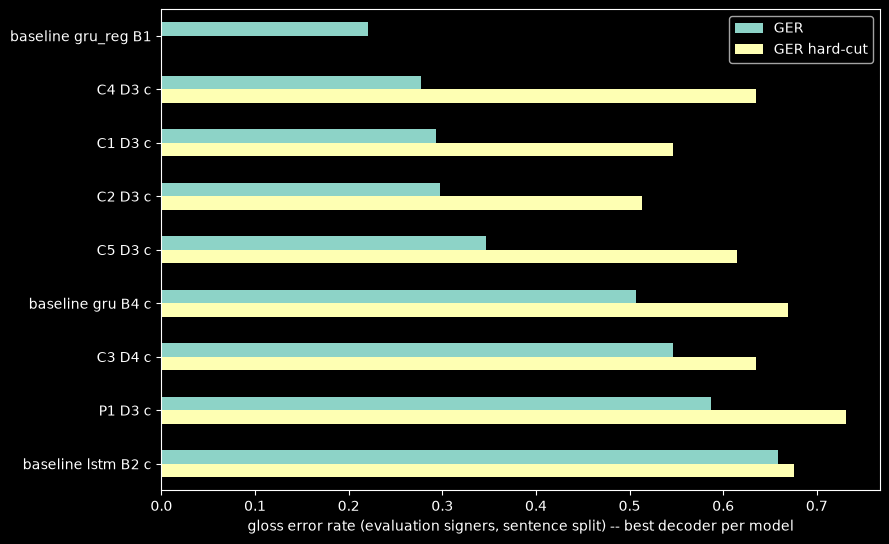

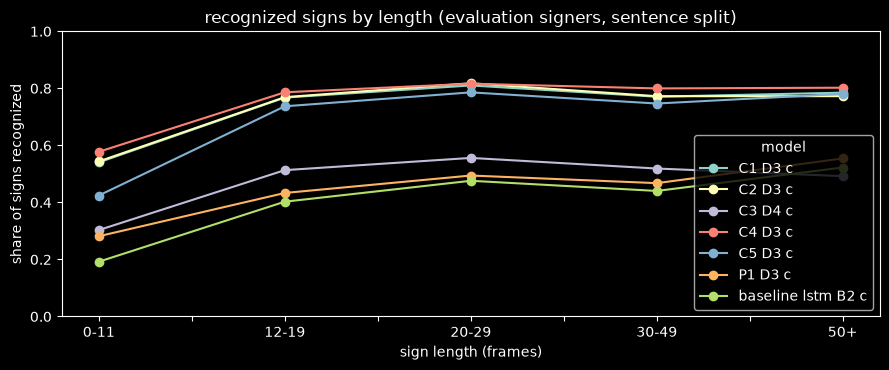

model  C1 D3 c  C2 D3 c  C3 D4 c  C4 D3 c  C5 D3 c  P1 D3 c  baseline lstm B2 c  share_of_signs
bin                                                                                            
0-11     0.541    0.544    0.303    0.578    0.424    0.281               0.192           0.248
12-19    0.768    0.769    0.513    0.786    0.737    0.433               0.403           0.219
20-29    0.810    0.818    0.556    0.816    0.786    0.494               0.476           0.198
30-49    0.771    0.772    0.519    0.800    0.747    0.468               0.440           0.147
50+      0.785    0.773    0.492    0.802    0.781    0.554               0.522           0.187


In [8]:
# ============================================================
# Figures: GER by model/decoder, and recognized-by-sign-length
# ============================================================
table = pd.read_csv(OUT / "final_table.csv")
top = table.loc[table.groupby("model")["GER"].idxmin()].sort_values("GER")
ax = top.set_index(top["model"] + " " + top["mode"] + np.where(top["collapse"], " c", ""))[["GER", "GER hard-cut"]].plot.barh(
    figsize=(9, 0.45 * len(top) + 1.5))
ax.invert_yaxis()
ax.set_xlabel("gloss error rate (evaluation signers, sentence split) -- best decoder per model")
plt.tight_layout()
plt.savefig(ASSETS / "ger_by_model.png", dpi=110)
plt.show()

bl = pd.read_csv(OUT / "by_length_signs.csv")
bins = CONFIG["length_bins"]
labels_ = [f"{a}-{b - 1}" if b < 10**6 else f"{a}+" for a, b in zip(bins[:-1], bins[1:])]
bl["bin"] = pd.cut(bl["length"], bins, right=False, labels=labels_)
tab = bl.groupby(["bin", "model"], observed=True)["correct"].mean().unstack()
share = bl[bl.model == bl.model.iloc[0]].groupby("bin", observed=True).size()
tab.to_csv(OUT / "by_length.csv")
ax = tab.plot(marker="o", figsize=(9, 3.8))
ax.set_xlabel("sign length (frames)")
ax.set_ylabel("share of signs recognized")
ax.set_ylim(0, 1)
ax.set_title("recognized signs by length (evaluation signers, sentence split)")
plt.tight_layout()
plt.savefig(ASSETS / "recognized_by_length.png", dpi=110)
plt.show()
print((tab.assign(share_of_signs=share / share.sum())).to_string(float_format="{:.3f}".format))